<a href="https://colab.research.google.com/github/JasminAcostaMendez26/Estad-stica-Verano/blob/main/Gym_members.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df= pd.read_csv('https://raw.githubusercontent.com/JasminAcostaMendez26/Estad-stica-Verano/refs/heads/main/gym_members_exercise_tracking.csv')
df

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74


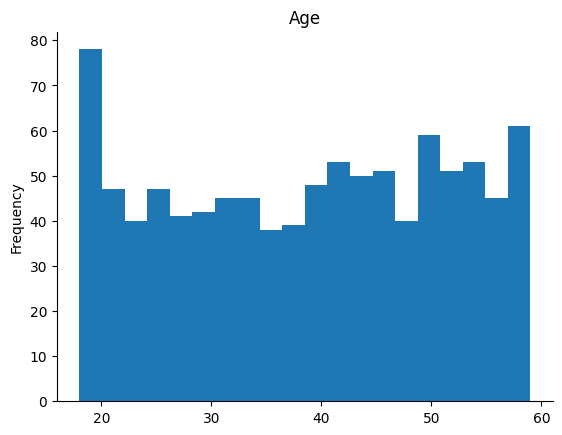

In [ ]:
# @title Age

from matplotlib import pyplot as plt
df['Age'].plot(kind='hist', bins=20, title='Age')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm
modelo_lineal = ols('Calories_Burned ~ C(Gender)', data=df ).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

ValueError: negative dimensions are not allowed

In [ ]:
df["Gender"].unique()

array([nan])

In [ ]:
from scipy.stats import shapiro
_,valor_p_sh=shapiro(modelo_lineal. resid)
print("valor_p_sh = ",valor_p_sh)

valor_p_sh =  2.4291767943152403e-05


In [ ]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['Gender'] == 'Male']['Calories_Burned']
grupo2 = df[df['Gender'] == 'Female']['Calories_Burned']

stat, p = levene(grupo1, grupo2)
print(f"p-valor de Levene: {p}")

p-valor de Levene: nan


/tmp/ipython-input-40-2497670072.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = levene(grupo1, grupo2)


In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['Calories_Burned'], groups=df['Gender'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

ValueError: 2 or more groups required for multiple comparisons

In [ ]:
df["Gender"]= df["Gender"].map({"Male": 2, "Female" :1})
df

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,NaN,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,NaN,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,NaN,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,NaN,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,NaN,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,NaN,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,NaN,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,NaN,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,NaN,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74


In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm
modelo_lineal = ols('Calories_Burned ~ C(Workout_Type)', data=df ).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
C(Workout_Type),3.0,2.116701e+05,70556.703442,0.949043,0.41624
Residual,969.0,7.204039e+07,74345.089042,NaN,NaN


valor-p (Shapiro) = 2.4291767943152403e-05


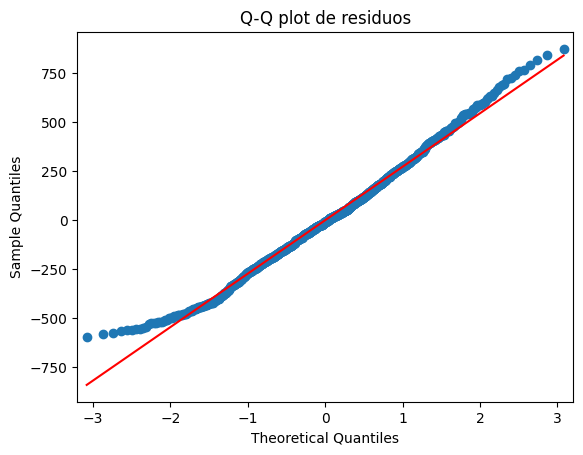

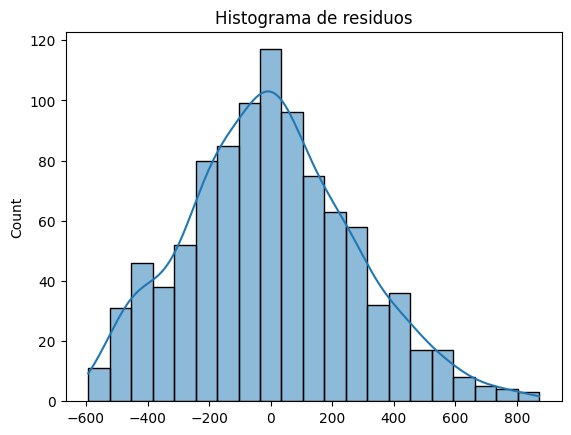

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['Workout_Type'] == 'Yoga']['Calories_Burned']
grupo2 = df[df['Workout_Type'] == 'HIIT']['Calories_Burned']
grup3 = df[df['Workout_Type'] == 'Cardio']['Calories_Burned']
grup4 = df[df['Workout_Type'] == 'Strength']['Calories_Burned']

stat, p = levene(grupo1, grupo2,grup3,grup4)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.788993613463197


   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1   group2  meandiff p-adj   lower    upper   reject
----------------------------------------------------------
  Cardio     HIIT  41.2917 0.3523 -23.1974 105.7809  False
  Cardio Strength  26.1839 0.6973 -35.7784  88.1463  False
  Cardio     Yoga  18.6746 0.8721 -44.5002  81.8494  False
    HIIT Strength -15.1078 0.9306 -79.4226  49.2071  False
    HIIT     Yoga -22.6171 0.8107 -88.1009  42.8666  False
Strength     Yoga  -7.5094   0.99 -70.5062  55.4875  False
----------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

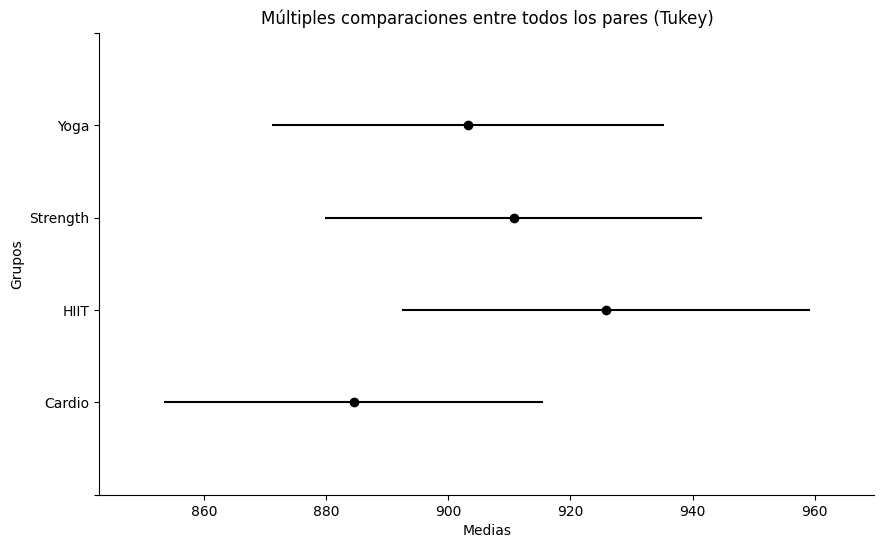

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['Calories_Burned'], groups=df['Workout_Type'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
df = df.drop(columns=['Workout_Type'])
df

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,NaN,88.3,1.71,180,157,60,1.69,1313.0,12.6,3.5,4,3,30.20
1,46,NaN,74.9,1.53,179,151,66,1.30,883.0,33.9,2.1,4,2,32.00
2,32,NaN,68.1,1.66,167,122,54,1.11,677.0,33.4,2.3,4,2,24.71
3,25,NaN,53.2,1.70,190,164,56,0.59,532.0,28.8,2.1,3,1,18.41
4,38,NaN,46.1,1.79,188,158,68,0.64,556.0,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,NaN,87.1,1.74,187,158,67,1.57,1364.0,10.0,3.5,4,3,28.77
969,25,NaN,66.6,1.61,184,166,56,1.38,1260.0,25.0,3.0,2,1,25.69
970,59,NaN,60.4,1.76,194,120,53,1.72,929.0,18.8,2.7,5,3,19.50
971,32,NaN,126.4,1.83,198,146,62,1.10,883.0,28.2,2.1,3,2,37.74


(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5]),
 [Text(0, 0.5, 'Age'),
  Text(0, 1.5, 'Gender'),
  Text(0, 2.5, 'Weight (kg)'),
  Text(0, 3.5, 'Height (m)'),
  Text(0, 4.5, 'Max_BPM'),
  Text(0, 5.5, 'Avg_BPM'),
  Text(0, 6.5, 'Resting_BPM'),
  Text(0, 7.5, 'Session_Duration (hours)'),
  Text(0, 8.5, 'Calories_Burned'),
  Text(0, 9.5, 'Fat_Percentage'),
  Text(0, 10.5, 'Water_Intake (liters)'),
  Text(0, 11.5, 'Workout_Frequency (days/week)'),
  Text(0, 12.5, 'Experience_Level'),
  Text(0, 13.5, 'BMI')])

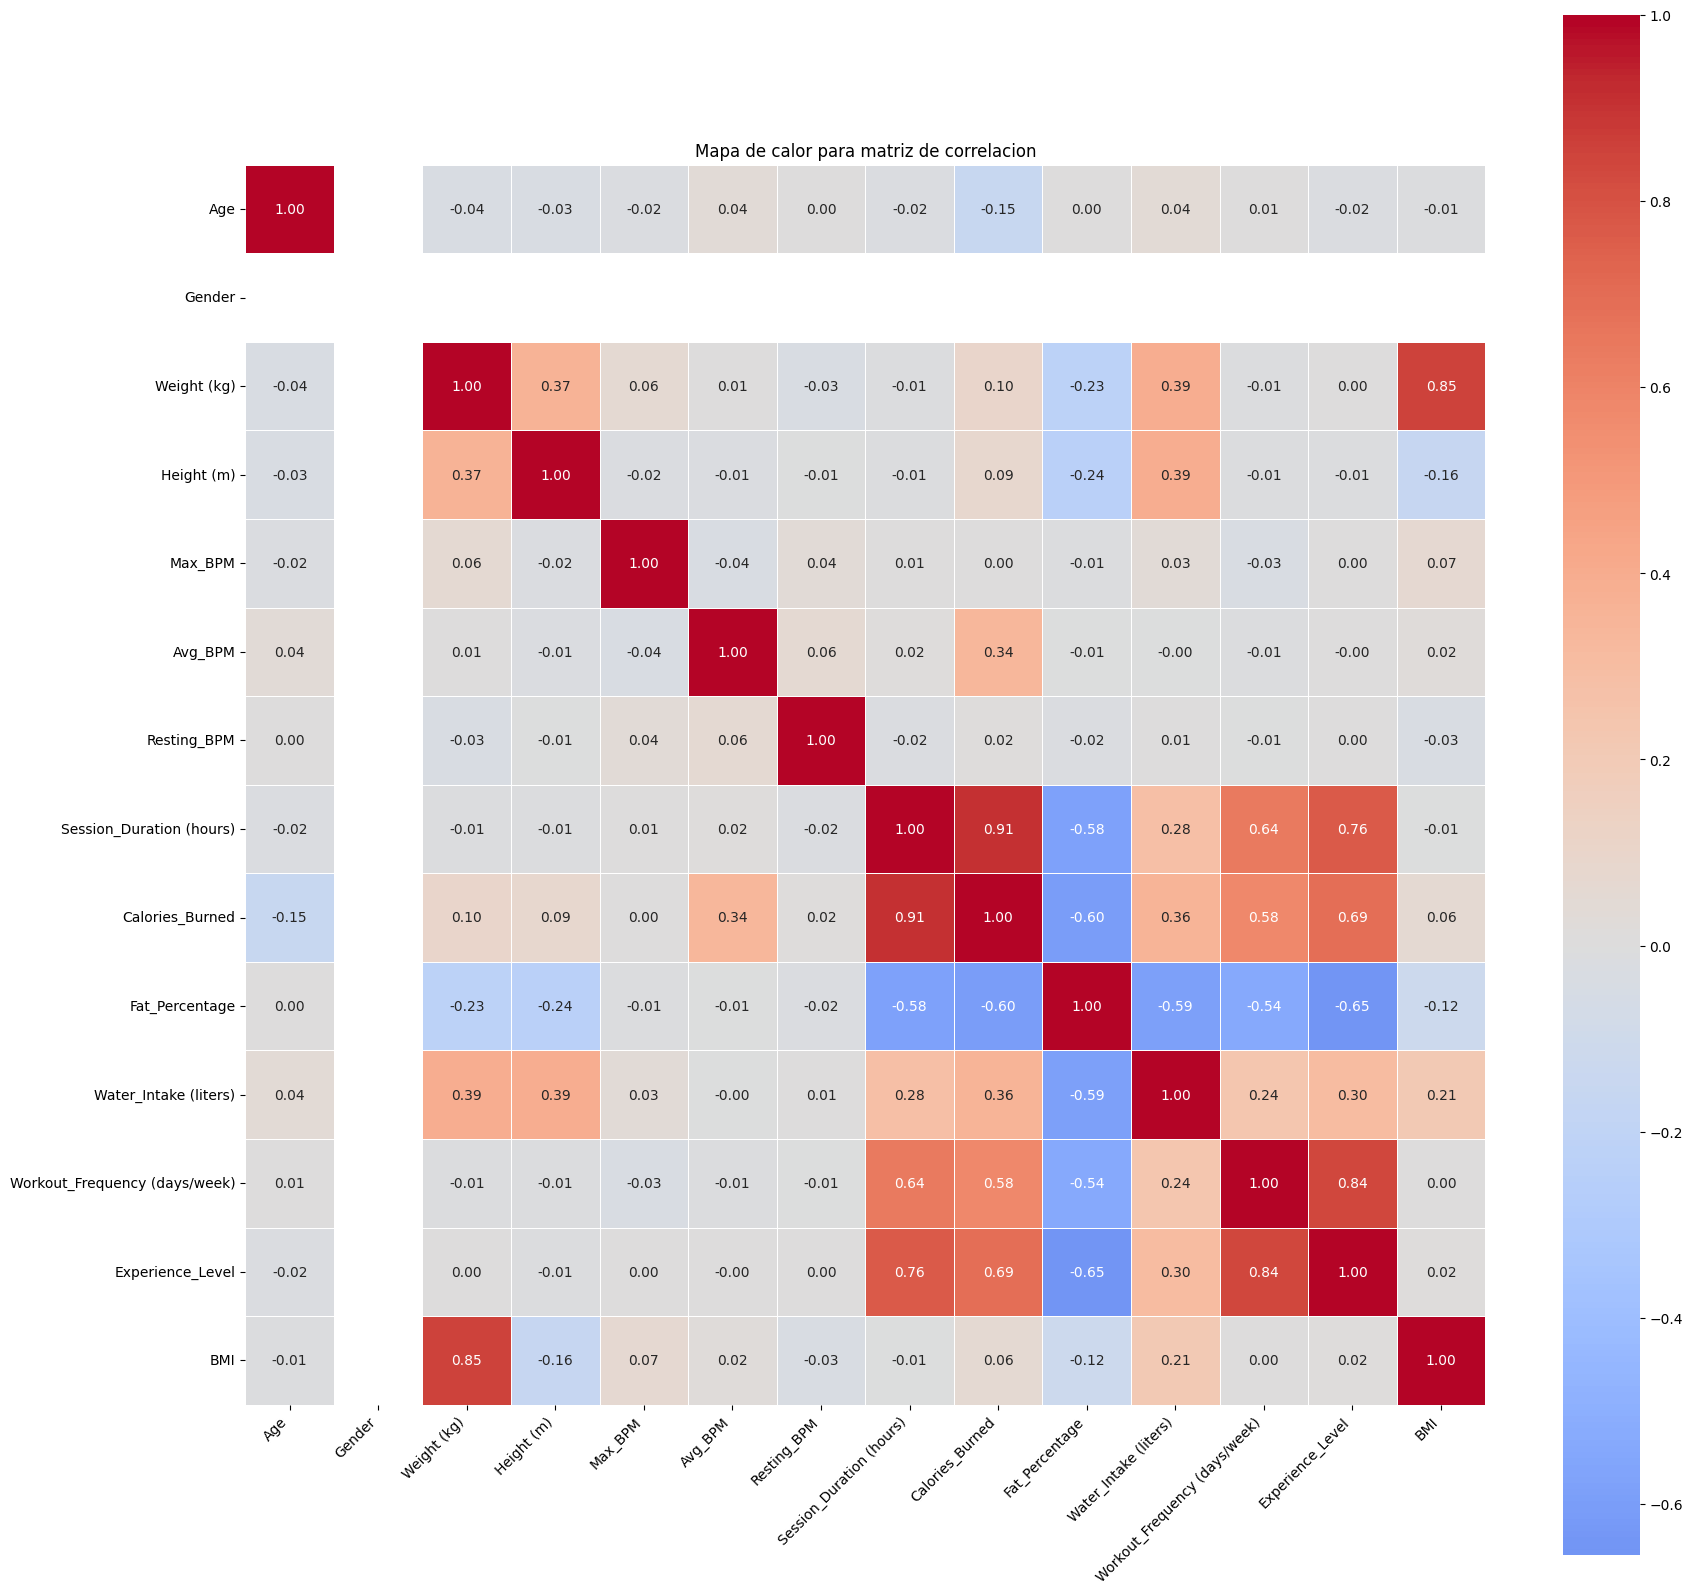

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

matriz_de_correlacion= df.corr()

plt.figure(figsize=(20,25), dpi=100)

sns.heatmap(
    matriz_de_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square= True,
    linewidths= 0.5,
    cbar_kws= {"shrink":0.8},
    center= 0)


plt.title("Mapa de calor para matriz de correlacion")
plt.xticks (rotation=45, ha="right")
plt.yticks (rotation=0)

     Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
0     56     NaN         88.3        1.71      180      157           60   
1     46     NaN         74.9        1.53      179      151           66   
2     32     NaN         68.1        1.66      167      122           54   
3     25     NaN         53.2        1.70      190      164           56   
4     38     NaN         46.1        1.79      188      158           68   
..   ...     ...          ...         ...      ...      ...          ...   
968   24     NaN         87.1        1.74      187      158           67   
969   25     NaN         66.6        1.61      184      166           56   
970   59     NaN         60.4        1.76      194      120           53   
971   32     NaN        126.4        1.83      198      146           62   
972   46     NaN         88.7        1.63      166      146           66   

     Session_Duration (hours)  Calories_Burned  Fat_Percentage  \
0                    

PatsyError: Error evaluating factor: NameError: name 'Session_Duration' is not defined
    Session_Duration (hours) ~ Calories_Burned
    ^^^^^^^^^^^^^^^^^^^^^^^^

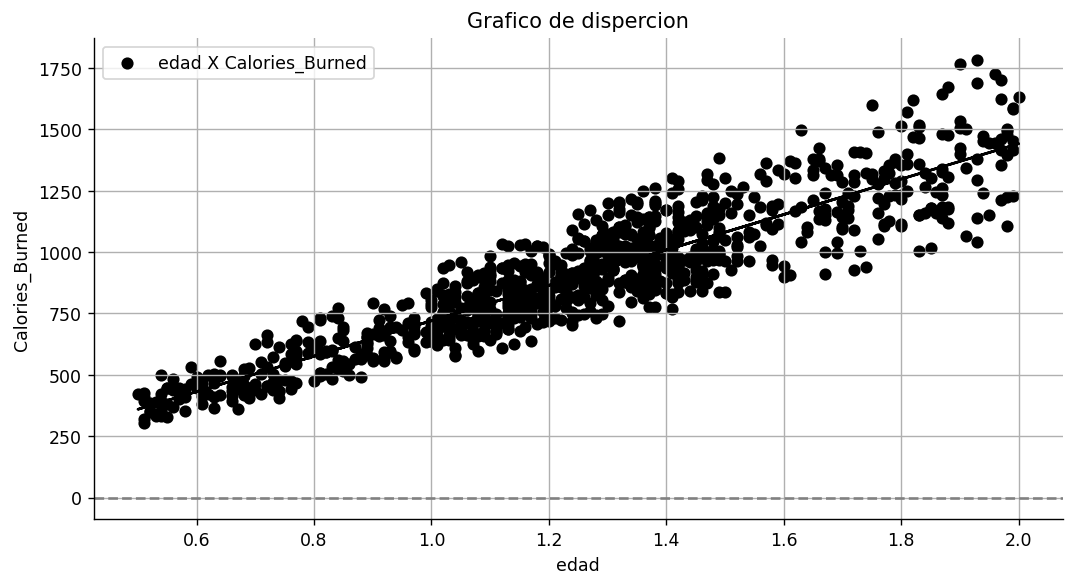

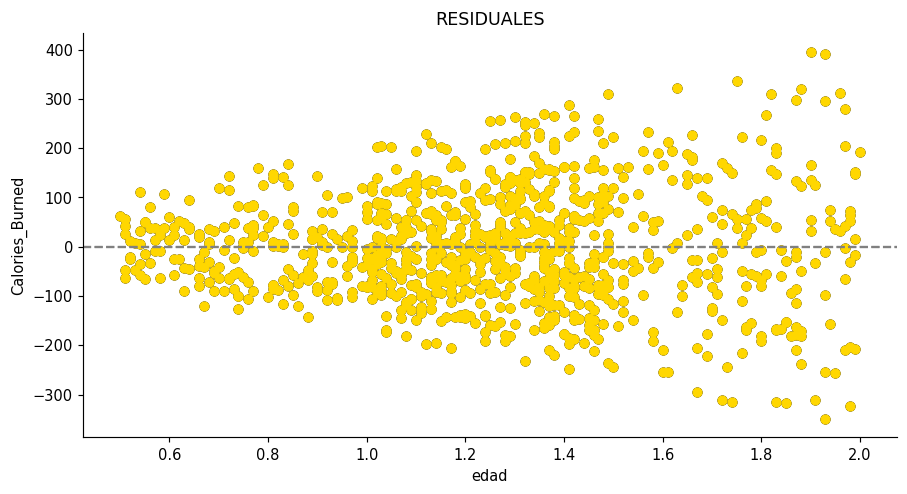

In [ ]:
x=df["Session_Duration (hours)"]
y=df["Calories_Burned"]
df.head(10)
print(df)
print("\n")

#REALIZAR UN DIAGRAMA DE DISPERSION PARA LOS DATOS
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5),dpi=125)
plt.scatter(x,y,
    label="edad X Calories_Burned",
    color="Black")
plt.title("Grafico de dispercion")
plt.xlabel("edad")
plt.ylabel("Calories_Burned")
plt.axhline(y=0, color="grey", linestyle="--")
plt.legend()
plt.grid()
df.head()
plt.gca().spines[["top","right"]].set_visible(False)

#3.- LOS DATOS SOPORTAN LA SUPOSICION DE LIENALIDAD
#NO

#4.- CALCULAR EL COEFICIENTE DE CORRELACION
from scipy.stats import pearsonr
r,_=pearsonr(x,y)
print( f"COEFICIENTE DE CORRELACION: {r: 0.4f}\n")

#6.- OBTENGA LA RECTA DE REGRESION AJUSTADA Y GRAFICAR SOBRE EL GRAFICO DE
#DISPERSION
import statsmodels.api as sm
x_constante=sm.add_constant(x)
modelo=sm.OLS(y,x_constante).fit()
yc=modelo.predict(x_constante)
plt.plot(x,yc, color="BLACK")

#5.- CALCULE EL COEFICIENTE DE DETERMINACION E INTERPRETE EL RESULTADO
from sklearn.metrics import r2_score
r2=r2_score(y,yc)
print( f"COEFICIENTE DE DETERMINACION: {r2: 0.4f} \n")

#7.-OBTENGA UN INTERVALO DE CONFIANZA DEL 95% PARA LA PENDIENTE DE LA RECTA DE
nivel_confianza= 0.95
intervalo_de_confianza=modelo.conf_int(alpha= 1 - nivel_confianza)
intervalo_de_confianza_b1=intervalo_de_confianza.iloc[1]
print(f"INTERVALO DE CONFIANZA DEL PARA b1 ES: {nivel_confianza:0.0%} \n")
print(f"{intervalo_de_confianza_b1[0]: 0.4f} < b1 < {intervalo_de_confianza_b1[1]: 0.4f} \n")

#8.- CALCULE LOS RESIDUALES Y TRACE UN NUEVO GRAFICO DE DISPERSION. COMENTE,
# PARECE QUE SE VERIFICAN LOS SUPUESTOS
residuales= modelo.resid
plt.figure(figsize=(10,5),dpi=105)
plt.scatter(x,residuales, color="Black")
plt.title("RESIDUALES")
plt.xlabel("edad")
plt.ylabel("Calories_Burned")
plt.axhline(y=0, color="grey", linestyle="--")
plt.scatter(x, residuales,
            label=" edad",
            color="gold")
plt.axhline(y=0, color="grey", linestyle="--")
plt.gca().spines[["top","right"]].set_visible(False)

#9.- REALIZAR LA PRUEBA DE SHAPIRO PARA LOS RESIDUALES Y COMENTE EL RESULTADO
from scipy.stats import shapiro
estadistico_shapiro, valor_p_sh = shapiro(residuales)
print("valor_p_sh:", valor_p_sh )
print("\n")
if valor_p_sh<0.05:
  print("Los datos no siguen una distribucion normal")
else:
  print("Los datos siguen una distribucion normal \n")

#10.-REALIZAR LA PRUEBA DE BREUSCHPAGAN PARA LOS RESIDUALES Y COMENTE LOS RESULTADOS
from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print("valor_p_bp:", valor_p_bp)
print("\n")
if valor_p_bp<0.05:
  print("Hay heteroscedasticidad")
else:
  print("Hay homosedasticidad \n")

#11.- UTILIZA LA RECTA DE REGRESION PARA INTERPOLAR DOS VALORES Y EXTRAPOLAR UNO
#COMENTA LOS RESULTADOS
print(f"Para x = 5, y = {modelo.predict([1,5])[0]}")
print(f"Para x = 8, y = {modelo.predict([1,8])[0]}")
print(f"Para x = 20, y = {modelo.predict([1,20])[0]}\n")\

#12.- REALIZAR TABLA ANOVA E INTERPRETAR EL RESULTADO
from statsmodels.formula.api import ols
modelo_lineal=ols(" Session_Duration (hours) ~ Calories_Burned", data=df).fit()
tabla_anova=sm.stats.anova_lm(modelo_lineal)
if valor_p_bp<0.05:
  print("No hay relacion entre X y Y")
else:
  print("Si hay relacion entre X y Y")
tabla_anova

modelo.predict([1,4])
print(modelo.get_prediction([1,4]).summary_frame(alpha=0.05))
